# Credit Risk Prediction — Exploratory Data Analysis

**Author:** Aluka Precious Oluchukwu
**Project:** Credit Risk ML System Exploratory Data Analysis

## Objectives

1. Understand the structure and quality of the German Credit Dataset
2. Identify class imbalance and its implications for model training
3. Explore distributions of numerical and categorical features
4. Detect outliers and missing values
5. Uncover relationships between features and credit risk outcome
6. Generate insights that inform feature engineering decisions

## Dataset Overview

The German Credit Dataset contains 1000 loan applicants assessed
for credit risk. Each applicant is classified as good risk or bad
risk based on a set of financial and personal attributes.

Source: UCI Machine Learning Repository — Statlog German Credit Data

## Why EDA Matters

Exploratory analysis is not optional in production ML systems.
Models trained on poorly understood data inherit all the biases,
errors, and structural problems in that data. Every modelling
decision made in later phases traces back to findings here.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Plot styling
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")

print(" All libraries imported successfully!")

 All libraries imported successfully!


In [2]:
# Load raw dataset
df = pd.read_excel("../data/raw/German Credit Data.xlsx")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (1000, 21)

Columns: ['checking account status', 'Duration in month', 'Credit history', 'Purpose', 'Credit amount', 'Savings account/bonds', 'employment', ' Installment', 'status n sex', ' Other debtors / guarantors', 'residence', 'Property', 'Age in years', 'Other installment plans', 'Housing', 'existing credits no.', 'Job', 'liability responsibles', 'Telephone', 'foreign worker', 'Category']


,checking account status,Duration in month,Credit history,Purpose,Credit amount,Savings account/bonds,employment,Installment,status n sex,Other debtors / guarantors,...,Property,Age in years,Other installment plans,Housing,existing credits no.,Job,liability responsibles,Telephone,foreign worker,Category
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [ ]:
# Quick Insights\EDA using pandas profiiling
from ydata_profiling import ProfileReport
profile = ProfileReport(df, title="German Credit Data - EDA Report", explorative = True)

profile.to_file("../data/processed/eda_report.html")
print("Profiling report saved! Open data/processed/eda_report.html in your browser.")
profile

In [3]:
# See all column names clearly
for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}")

1. checking account status
2. Duration in month
3. Credit history
4. Purpose
5. Credit amount
6. Savings account/bonds
7. employment
8.  Installment
9. status n sex
10.  Other debtors / guarantors
11. residence
12. Property
13. Age in years
14. Other installment plans
15. Housing
16. existing credits no.
17. Job
18. liability responsibles
19. Telephone
20. foreign worker
21. Category


In [4]:
# Strip spaces from column names AND cell values 
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

df.columns

Index(['checking account status', 'Duration in month', 'Credit history',
       'Purpose', 'Credit amount', 'Savings account/bonds', 'employment',
       'Installment', 'status n sex', 'Other debtors / guarantors',
       'residence', 'Property', 'Age in years', 'Other installment plans',
       'Housing', 'existing credits no.', 'Job', 'liability responsibles',
       'Telephone', 'foreign worker', 'Category'],
      dtype='object')

In [5]:
print("Cleaned columns names")
for i, col in enumerate(df.columns):
    print(f"{i+1}: '{col}'")

Cleaned columns names
1: 'checking account status'
2: 'Duration in month'
3: 'Credit history'
4: 'Purpose'
5: 'Credit amount'
6: 'Savings account/bonds'
7: 'employment'
8: 'Installment'
9: 'status n sex'
10: 'Other debtors / guarantors'
11: 'residence'
12: 'Property'
13: 'Age in years'
14: 'Other installment plans'
15: 'Housing'
16: 'existing credits no.'
17: 'Job'
18: 'liability responsibles'
19: 'Telephone'
20: 'foreign worker'
21: 'Category'


In [6]:
# Striping spaces from values inside categorical columns 
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = df[col].str.strip()

# Verifing raw values are clean before mapping
print("Raw values after stripping — ready for mapping:")
for col in categorical_cols:
    print(f"{col}: {df[col].unique().tolist()}")

Raw values after stripping — ready for mapping:
checking account status: ['A11', 'A12', 'A14', 'A13']
Credit history: ['A34', 'A32', 'A33', 'A30', 'A31']
Purpose: ['A43', 'A46', 'A42', 'A40', 'A41', 'A49', 'A44', 'A45', 'A410', 'A48']
Savings account/bonds: ['A65', 'A61', 'A63', 'A64', 'A62']
employment: ['A75', 'A73', 'A74', 'A71', 'A72']
status n sex: ['A93', 'A92', 'A91', 'A94']
Other debtors / guarantors: ['A101', 'A103', 'A102']
Property: ['A121', 'A122', 'A124', 'A123']
Other installment plans: ['A143', 'A141', 'A142']
Housing: ['A152', 'A153', 'A151']
Job: ['A173', 'A172', 'A174', 'A171']
Telephone: ['A192', 'A191']
foreign worker: ['A201', 'A202']


In [7]:
# Check data types and missing values
print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nShape:", df.shape)

Data Types:
checking account status       object
Duration in month              int64
Credit history                object
Purpose                       object
Credit amount                  int64
Savings account/bonds         object
employment                    object
Installment                    int64
status n sex                  object
Other debtors / guarantors    object
residence                      int64
Property                      object
Age in years                   int64
Other installment plans       object
Housing                       object
existing credits no.           int64
Job                           object
liability responsibles         int64
Telephone                     object
foreign worker                object
Category                       int64
dtype: object

Missing Values:
checking account status       0
Duration in month             0
Credit history                0
Purpose                       0
Credit amount                 0
Savings account/bond

In [8]:

# Check unique values in categorical columns
print("\n--- Unique Values in Categorical Columns ---")
categorical_cols = df.select_dtypes(include="object").columns
for col in categorical_cols:
    print(f"\n{col}: {df[col].unique()}")


--- Unique Values in Categorical Columns ---

checking account status: ['A11' 'A12' 'A14' 'A13']

Credit history: ['A34' 'A32' 'A33' 'A30' 'A31']

Purpose: ['A43' 'A46' 'A42' 'A40' 'A41' 'A49' 'A44' 'A45' 'A410' 'A48']

Savings account/bonds: ['A65' 'A61' 'A63' 'A64' 'A62']

employment: ['A75' 'A73' 'A74' 'A71' 'A72']

status n sex: ['A93' 'A92' 'A91' 'A94']

Other debtors / guarantors: ['A101' 'A103' 'A102']

Property: ['A121' 'A122' 'A124' 'A123']

Other installment plans: ['A143' 'A141' 'A142']

Housing: ['A152' 'A153' 'A151']

Job: ['A173' 'A172' 'A174' 'A171']

Telephone: ['A192' 'A191']

foreign worker: ['A201' 'A202']


##  Data Dictionary — Feature Descriptions & Code Mappings

Before decoding our categorical columns, we document the meaning of every feature 
and every coded value according to the official UCI German Credit Dataset 
documentation published by Professor Hans Hofmann, University of Hamburg.

Understanding what each feature represents in real-world banking terms is essential 
for making sound preprocessing decisions and for interpreting our model's outputs 
meaningfully. A model that predicts "A11" is less useful to a bank than a model 
that predicts "checking account balance less than 0 DM".

---

###  Target Variable

| Code | Meaning |
|------|---------|
| 1 | Good Credit Risk — applicant is likely to repay the loan |
| 2 | Bad Credit Risk — applicant is likely to default on the loan |

> We recode this to 0 (good) and 1 (bad) to follow the universal ML convention 
> where 1 represents the positive class — the outcome we are most interested 
> in detecting.

---

###  Feature 1 — Checking Account Status
*Represents the balance status of the applicant's checking account.*

| Code | Meaning |
|------|---------|
| A11 | Less than 0 DM (negative balance) |
| A12 | 0 to 200 DM |
| A13 | Greater than 200 DM or salary assignment for at least 1 year |
| A14 | No checking account |

---

###  Feature 2 — Credit History
*Represents the applicant's track record with previous credits.*

| Code | Meaning |
|------|---------|
| A30 | No credits taken or all credits paid back duly |
| A31 | All credits at this bank paid back duly |
| A32 | Existing credits paid back duly till now |
| A33 | Delay in paying off in the past |
| A34 | Critical account or other credits existing |

---

###  Feature 3 — Purpose of Loan
*Represents what the applicant intends to use the loan for.*

| Code | Meaning |
|------|---------|
| A40 | New car |
| A41 | Used car |
| A42 | Furniture or equipment |
| A43 | Radio or television |
| A44 | Domestic appliances |
| A45 | Repairs |
| A46 | Education |
| A47 | Vacation |
| A48 | Retraining |
| A49 | Business |
| A410 | Others |

---

###  Feature 4 — Savings Account / Bonds
*Represents the balance in the applicant's savings account or bonds.*

| Code | Meaning |
|------|---------|
| A61 | Less than 100 DM |
| A62 | 100 to 500 DM |
| A63 | 500 to 1000 DM |
| A64 | Greater than 1000 DM |
| A65 | Unknown or no savings account |

---

###  Feature 5 — Employment Status
*Represents how long the applicant has been in their current employment.*

| Code | Meaning |
|------|---------|
| A71 | Unemployed |
| A72 | Less than 1 year |
| A73 | 1 to 4 years |
| A74 | 4 to 7 years |
| A75 | Greater than 7 years |

---

###  Feature 6 — Status and Sex
*Represents the marital status and gender of the applicant.*

| Code | Meaning |
|------|---------|
| A91 | Male — divorced or separated |
| A92 | Female — divorced, separated, or married |
| A93 | Male — single |
| A94 | Male — married or widowed |
| A95 | Female — single |

---

###  Feature 7 — Other Debtors / Guarantors
*Represents whether there is a co-applicant or guarantor on the loan.*

| Code | Meaning |
|------|---------|
| A101 | None |
| A102 | Co-applicant |
| A103 | Guarantor |

---

###  Feature 8 — Property
*Represents the most valuable property owned by the applicant.*

| Code | Meaning |
|------|---------|
| A121 | Real estate |
| A122 | Building society savings agreement or life insurance |
| A123 | Car or other property |
| A124 | Unknown or no property |

---

###  Feature 9 — Other Installment Plans
*Represents whether the applicant has other installment payment obligations.*

| Code | Meaning |
|------|---------|
| A141 | Bank |
| A142 | Stores |
| A143 | None |

---

###  Feature 10 — Housing
*Represents the applicant's housing situation.*

| Code | Meaning |
|------|---------|
| A151 | Rent |
| A152 | Own |
| A153 | For free |

---

###  Feature 11 — Job Type
*Represents the applicant's employment category and skill level.*

| Code | Meaning |
|------|---------|
| A171 | Unemployed or unskilled — non-resident |
| A172 | Unskilled — resident |
| A173 | Skilled employee or official |
| A174 | Management, self-employed, highly qualified employee, or officer |

---

###  Feature 12 — Telephone
*Represents whether the applicant has a registered telephone number.*

| Code | Meaning |
|------|---------|
| A191 | None |
| A192 | Yes — registered under the customer's name |

---

###  Feature 13 — Foreign Worker
*Represents whether the applicant is a foreign worker.*

| Code | Meaning |
|------|---------|
| A201 | Yes |
| A202 | No |

---

###  Numerical Features
*These features require no decoding as they are already in their natural numerical form.*

| Feature | Description | Unit |
|---------|-------------|------|
| Duration in month | Duration of the loan | Months |
| Credit amount | Total loan amount requested | Deutsche Marks (DM) |
| Installment | Installment rate as percentage of disposable income | % |
| Age in years | Age of the applicant | Years |
| residence | Number of years at current residence | Years |
| existing credits no. | Number of existing credits at this bank | Count |
| liability responsibles | Number of people the applicant is liable to provide maintenance for | Count |

---

> **Source:** UCI Machine Learning Repository — Statlog (German Credit Data) Dataset  
> **Original Creator:** Professor Hans Hofmann, University of Hamburg, Germany  
> **Link:** https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data

### ─── Decode all categorical columns using UCI data dictionary ─────────────────

In [9]:
# ─── Mapping dictionaries ────
checking_map = {
    'A11': 'less_than_0_DM',
    'A12': '0_to_200_DM',
    'A13': 'greater_than_200_DM',
    'A14': 'no_checking_account'
}
credit_history_map = {
    'A30': 'no_credits_taken',
    'A31': 'all_credits_paid_duly',
    'A32': 'existing_credits_paid_duly',
    'A33': 'delay_in_paying',
    'A34': 'critical_account'
}
purpose_map = {
    'A40': 'car_new', 'A41': 'car_used', 'A42': 'furniture',
    'A43': 'radio_tv', 'A44': 'domestic_appliances', 'A45': 'repairs',
    'A46': 'education', 'A47': 'vacation', 'A48': 'retraining',
    'A49': 'business', 'A410': 'others'
}
savings_map = {
    'A61': 'less_than_100_DM', 'A62': '100_to_500_DM',
    'A63': '500_to_1000_DM', 'A64': 'greater_than_1000_DM',
    'A65': 'unknown_no_savings'
}
employment_map = {
    'A71': 'unemployed', 'A72': 'less_than_1_year',
    'A73': '1_to_4_years', 'A74': '4_to_7_years',
    'A75': 'greater_than_7_years'
}
status_sex_map = {
    'A91': 'male_divorced_separated',
    'A92': 'female_divorced_separated_married',
    'A93': 'male_single', 'A94': 'male_married_widowed',
    'A95': 'female_single'
}
other_debtors_map = {
    'A101': 'none', 'A102': 'co_applicant', 'A103': 'guarantor'
}
property_map = {
    'A121': 'real_estate', 'A122': 'savings_insurance',
    'A123': 'car_other', 'A124': 'unknown_no_property'
}
installment_plans_map = {
    'A141': 'bank', 'A142': 'stores', 'A143': 'none'
}
housing_map = {
    'A151': 'rent', 'A152': 'own', 'A153': 'for_free'
}
job_map = {
    'A171': 'unemployed_unskilled_non_resident',
    'A172': 'unskilled_resident', 'A173': 'skilled_employee',
    'A174': 'management_self_employed'
}
telephone_map = {'A191': 'none', 'A192': 'yes_registered'}
foreign_worker_map = {'A201': 'yes', 'A202': 'no'}

print("Mapping Sucessful")

Mapping Sucessful


In [10]:
# ─── Apply all mappings ───────────────────────────────────────────────────────
df['checking account status'] = df['checking account status'].map(checking_map)
df['Credit history'] = df['Credit history'].map(credit_history_map)
df['Purpose'] = df['Purpose'].map(purpose_map)
df['Savings account/bonds'] = df['Savings account/bonds'].map(savings_map)
df['employment'] = df['employment'].map(employment_map)
df['status n sex'] = df['status n sex'].map(status_sex_map)
df['Other debtors / guarantors'] = df['Other debtors / guarantors'].map(other_debtors_map)
df['Property'] = df['Property'].map(property_map)
df['Other installment plans'] = df['Other installment plans'].map(installment_plans_map)
df['Housing'] = df['Housing'].map(housing_map)
df['Job'] = df['Job'].map(job_map)
df['Telephone'] = df['Telephone'].map(telephone_map)
df['foreign worker'] = df['foreign worker'].map(foreign_worker_map)

# ─── Recode target variable ───────────────────────────────────────────────────
df['Category'] = df['Category'].map({1: 0, 2: 1})

# ─── Final verification ───────────────────────────────────────────────────────
print("NaN check — every value must be 0:")
print(df.isnull().sum())
print("\nTarget distribution:")
print(df['Category'].value_counts())
print("\nFirst 3 rows:")
df.head(3)

NaN check — every value must be 0:
checking account status       0
Duration in month             0
Credit history                0
Purpose                       0
Credit amount                 0
Savings account/bonds         0
employment                    0
Installment                   0
status n sex                  0
Other debtors / guarantors    0
residence                     0
Property                      0
Age in years                  0
Other installment plans       0
Housing                       0
existing credits no.          0
Job                           0
liability responsibles        0
Telephone                     0
foreign worker                0
Category                      0
dtype: int64

Target distribution:
Category
0    700
1    300
Name: count, dtype: int64

First 3 rows:


,checking account status,Duration in month,Credit history,Purpose,Credit amount,Savings account/bonds,employment,Installment,status n sex,Other debtors / guarantors,...,Property,Age in years,Other installment plans,Housing,existing credits no.,Job,liability responsibles,Telephone,foreign worker,Category
0,less_than_0_DM,6,critical_account,radio_tv,1169,unknown_no_savings,greater_than_7_years,4,male_single,none,...,real_estate,67,none,own,2,skilled_employee,1,yes_registered,yes,0
1,0_to_200_DM,48,existing_credits_paid_duly,radio_tv,5951,less_than_100_DM,1_to_4_years,2,female_divorced_separated_married,none,...,real_estate,22,none,own,1,skilled_employee,1,none,yes,1
2,no_checking_account,12,critical_account,education,2096,less_than_100_DM,4_to_7_years,2,male_single,none,...,real_estate,49,none,own,1,unskilled_resident,2,none,yes,0


In [13]:
df.tail(20)

,checking account status,Duration in month,Credit history,Purpose,Credit amount,Savings account/bonds,employment,Installment,status n sex,Other debtors / guarantors,...,Property,Age in years,Other installment plans,Housing,existing credits no.,Job,liability responsibles,Telephone,foreign worker,Category
980,A12,30,A34,A42,8386,A61,A74,2,A93,A101,...,A122,49,A143,A152,1,A173,1,A191,A201,2
981,A14,48,A32,A49,4844,A61,A71,3,A93,A101,...,A123,33,A141,A151,1,A174,1,A192,A201,2
982,A13,21,A32,A40,2923,A62,A73,1,A92,A101,...,A123,28,A141,A152,1,A174,1,A192,A201,1
983,A11,36,A32,A41,8229,A61,A73,2,A93,A101,...,A122,26,A143,A152,1,A173,2,A191,A201,2
984,A14,24,A34,A42,2028,A61,A74,2,A93,A101,...,A122,30,A143,A152,2,A172,1,A191,A201,1
985,A11,15,A34,A42,1433,A61,A73,4,A92,A101,...,A122,25,A143,A151,2,A173,1,A191,A201,1
986,A13,42,A30,A49,6289,A61,A72,2,A91,A101,...,A122,33,A143,A152,2,A173,1,A191,A201,1
987,A14,13,A32,A43,1409,A62,A71,2,A92,A101,...,A121,64,A143,A152,1,A173,1,A191,A201,1
988,A11,24,A32,A41,6579,A61,A71,4,A93,A101,...,A124,29,A143,A153,1,A174,1,A192,A201,1
989,A12,24,A34,A43,1743,A61,A75,4,A93,A101,...,A122,48,A143,A152,2,A172,1,A191,A201,1


In [12]:
df.describe()

,Duration in month,Credit amount,Installment,residence,Age in years,existing credits no.,liability responsibles,Category
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


In [11]:
print(df['Category'].value_counts())

Category
0    700
1    300
Name: count, dtype: int64


Saving cleaned data as csv file

In [12]:
df.to_csv(r"C:\Users\DOUBLE J\Documents\data-projects\credit-risk-ml-system\data\processed\Cleaned_credit_risk_data.csv", index=False)

### Visualisation 1 — Credit Risk Class Distribution

The first and most critical visualisation in any classification project is the 
distribution of the target variable. Before any modelling begins, we must 
understand how balanced or imbalanced our classes are, because this directly 
determines our preprocessing strategy, our choice of evaluation metrics, and 
our approach to model training.

We visualise the class distribution using two complementary charts — a bar chart 
showing exact counts and a pie chart showing percentage proportions — to give 
both the absolute and relative picture of the imbalance simultaneously.

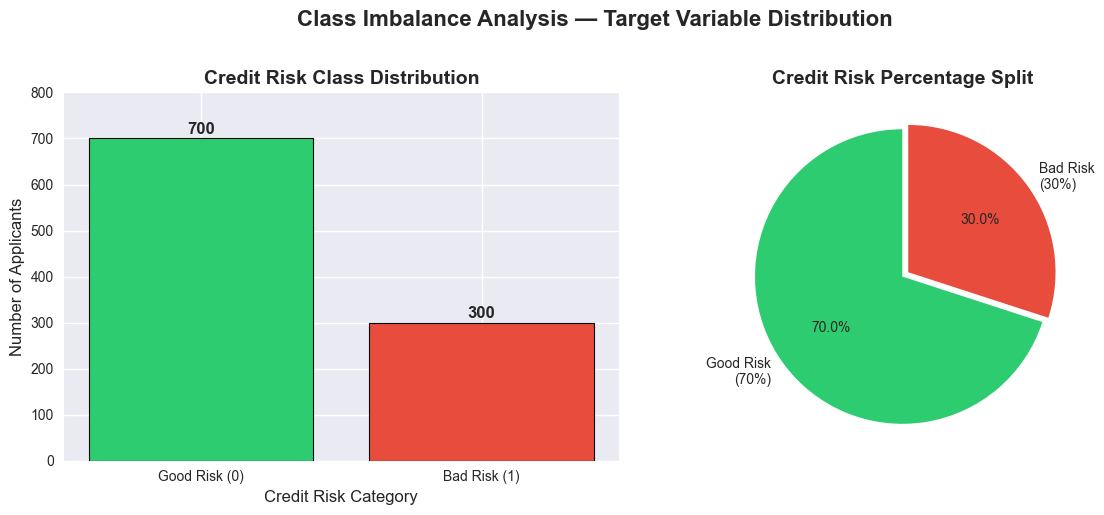

Chart saved successfully!


In [ ]:
# ─── Figure 1: Credit Risk Class Distribution ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
category_counts = df['Category'].value_counts()
axes[0].bar(['Good Risk (0)', 'Bad Risk (1)'], 
            category_counts.values,
            color=['#2ecc71', '#e74c3c'], 
            edgecolor='black', linewidth=0.8)
axes[0].set_title('Credit Risk Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Credit Risk Category', fontsize=12)
axes[0].set_ylabel('Number of Applicants', fontsize=12)
axes[0].set_ylim(0, 800)
for i, v in enumerate(category_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold', fontsize=12)

# Percentage pie chart
axes[1].pie(category_counts.values,
            labels=['Good Risk\n(70%)', 'Bad Risk\n(30%)'],
            colors=["#32c26e", '#e74c3c'],
            autopct='%1.1f%%',
            startangle=90,
            explode=(0, 0.05))
axes[1].set_title('Credit Risk Percentage Split', fontsize=14, fontweight='bold')

plt.suptitle('Class Imbalance Analysis — Target Variable Distribution',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved successfully!")

**Finding:** The target variable is imbalanced at a 70/30 ratio — 700 good credit 
risks versus 300 bad credit risks. This confirms that raw accuracy is a misleading 
metric for this problem, since a naive model predicting "good risk" for every 
applicant would achieve 70% accuracy without learning anything meaningful.

**Modelling implication:** We will apply SMOTE exclusively to the training set 
to balance the class distribution before model training, and will prioritise 
Recall, F1 Score, and AUC-ROC as our primary evaluation metrics rather than 
accuracy.

### Visualisation 2 — Credit Amount Distribution by Risk Category

Credit amount is one of the most intuitively important features in any credit 
risk model — the size of the loan a person requests should logically relate to 
their ability and likelihood of repayment. We examine how the distribution of 
credit amounts differs between good and bad credit risks using a histogram to 
show the shape of each distribution and a boxplot to reveal the spread, median, 
and presence of outliers for each group.

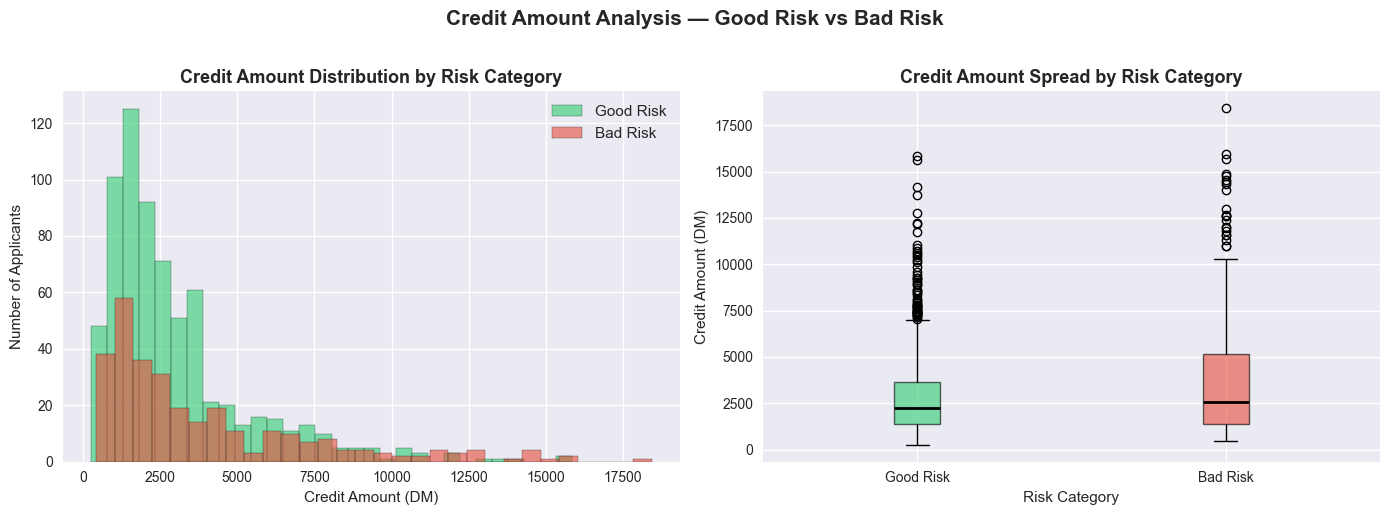

Chart saved successfully!


In [16]:
# ─── Figure 2: Credit Amount Distribution by Risk Category ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
for category, color, label in zip([0, 1],
                                   ['#2ecc71', '#e74c3c'],
                                   ['Good Risk', 'Bad Risk']):
    axes[0].hist(df[df['Category'] == category]['Credit amount'],
                bins=30, alpha=0.6, color=color, label=label, edgecolor='black')

axes[0].set_title('Credit Amount Distribution by Risk Category',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Credit Amount (DM)', fontsize=11)
axes[0].set_ylabel('Number of Applicants', fontsize=11)
axes[0].legend(fontsize=11)

# Boxplot — fixed version
good_risk = df[df['Category'] == 0]['Credit amount']
bad_risk = df[df['Category'] == 1]['Credit amount']

bp = axes[1].boxplot([good_risk, bad_risk],
                labels=['Good Risk', 'Bad Risk'],
                patch_artist=True,
                medianprops=dict(color='black', linewidth=2))

bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('#e74c3c')
bp['boxes'][1].set_alpha(0.6)

axes[1].set_title('Credit Amount Spread by Risk Category',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Risk Category', fontsize=11)
axes[1].set_ylabel('Credit Amount (DM)', fontsize=11)

plt.suptitle('Credit Amount Analysis — Good Risk vs Bad Risk',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/02_credit_amount_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved successfully!")

**Finding:** Both good and bad credit risks show right-skewed distributions 
concentrated at lower loan amounts, with long tails extending toward higher 
values. Bad credit risks show a slightly heavier presence at higher loan amounts, 
suggesting that larger loans carry moderately higher default risk. The boxplot 
reveals significant outliers in both groups — applicants borrowing amounts far 
above the typical range.

**Modelling implication:** The right skew and presence of outliers in Credit 
amount suggest that a log transformation may improve model performance for 
linear algorithms like Logistic Regression by making the distribution more 
symmetrical. Tree-based models such as Random Forest and Gradient Boosting 
are naturally robust to this skew and will not require transformation.

### Visualisation 3 — Age Distribution by Risk Category

Age is one of the most intuitively significant demographic features in credit 
risk assessment. Younger borrowers typically have shorter employment histories, 
lower savings, and less established financial habits compared to older borrowers 
— all factors that could influence their ability to repay a loan.

We examine how age is distributed across good and bad credit risk groups using 
a histogram to reveal the shape and concentration of each group's age profile, 
and a boxplot to compare the median age, spread, and outliers between the two 
risk categories.

The key analytical question this chart answers is: do good and bad credit risks 
differ meaningfully in their age profiles, and if so, how should that inform 
our feature engineering decisions?

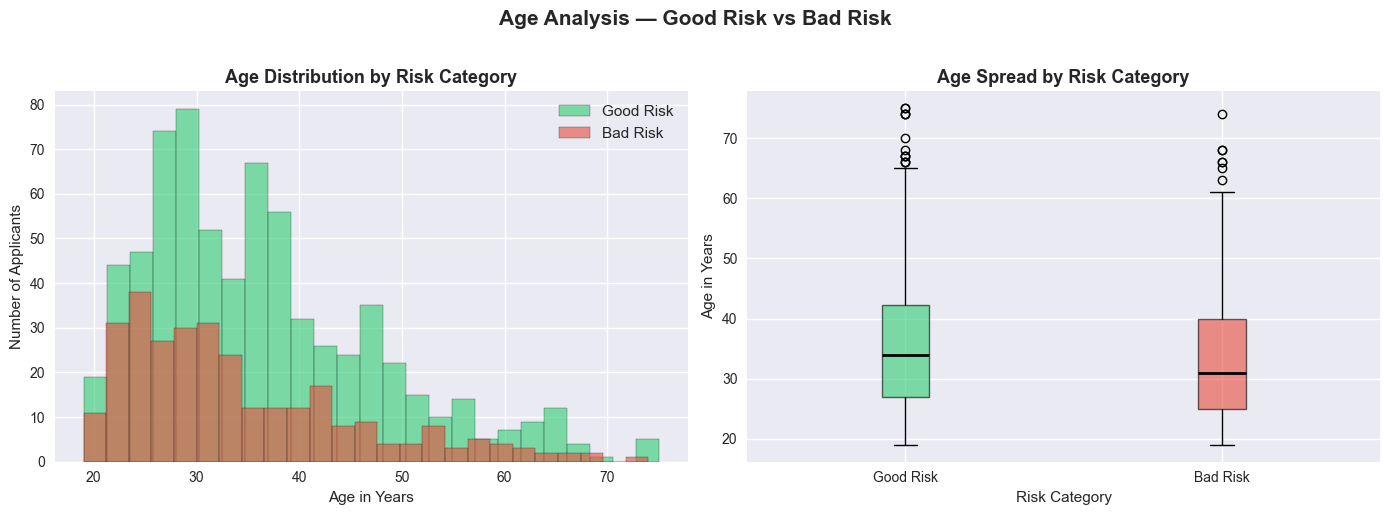

Chart saved successfully!


In [17]:
# ─── Figure 3: Age Distribution by Risk Category ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
for category, color, label in zip([0, 1],
                                   ['#2ecc71', '#e74c3c'],
                                   ['Good Risk', 'Bad Risk']):
    axes[0].hist(df[df['Category'] == category]['Age in years'],
                bins=25, alpha=0.6, color=color, label=label, edgecolor='black')

axes[0].set_title('Age Distribution by Risk Category',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age in Years', fontsize=11)
axes[0].set_ylabel('Number of Applicants', fontsize=11)
axes[0].legend(fontsize=11)

# Boxplot
good_age = df[df['Category'] == 0]['Age in years']
bad_age = df[df['Category'] == 1]['Age in years']

bp = axes[1].boxplot([good_age, bad_age],
                labels=['Good Risk', 'Bad Risk'],
                patch_artist=True,
                medianprops=dict(color='black', linewidth=2))

bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('#e74c3c')
bp['boxes'][1].set_alpha(0.6)

axes[1].set_title('Age Spread by Risk Category',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Risk Category', fontsize=11)
axes[1].set_ylabel('Age in Years', fontsize=11)

plt.suptitle('Age Analysis — Good Risk vs Bad Risk',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/03_age_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved successfully!")

**Finding:** Good credit risk applicants tend to be older than bad credit risk 
applicants. The histogram shows bad risk applicants are more heavily concentrated 
in the 19 to 35 age range, while good risk applicants are more evenly distributed 
across all age groups with stronger representation in the 30 to 60 range. The 
boxplot confirms this — the median age of good risk applicants is noticeably 
higher than that of bad risk applicants. Both groups contain outliers representing 
unusually old applicants relative to the typical borrower in the dataset.

**Modelling implication:** Age carries meaningful predictive signal for credit 
risk — younger applicants show a higher tendency toward default, possibly 
reflecting lower financial stability and less established credit history. This 
feature should be retained and will likely show moderate to high importance 
in our trained models. During feature engineering we will consider binning age 
into meaningful groups such as young adults (19-30), middle-aged (31-50), and 
senior (51+) to capture the non-linear relationship between age and credit risk 
more effectively.

### Visualisation 4 — Loan Purpose by Risk Category

The purpose of a loan is a critical feature in credit risk assessment. Different 
loan purposes carry inherently different risk profiles — a loan taken for 
retraining or education may carry different repayment dynamics compared to one 
taken for a new car or vacation.

We examine how loan purpose distributes across good and bad credit risk categories 
using a grouped bar chart and a stacked percentage chart. The key analytical 
question is: which loan purposes are associated with the highest default rates, 
and which purposes are predominantly taken by good credit risks?

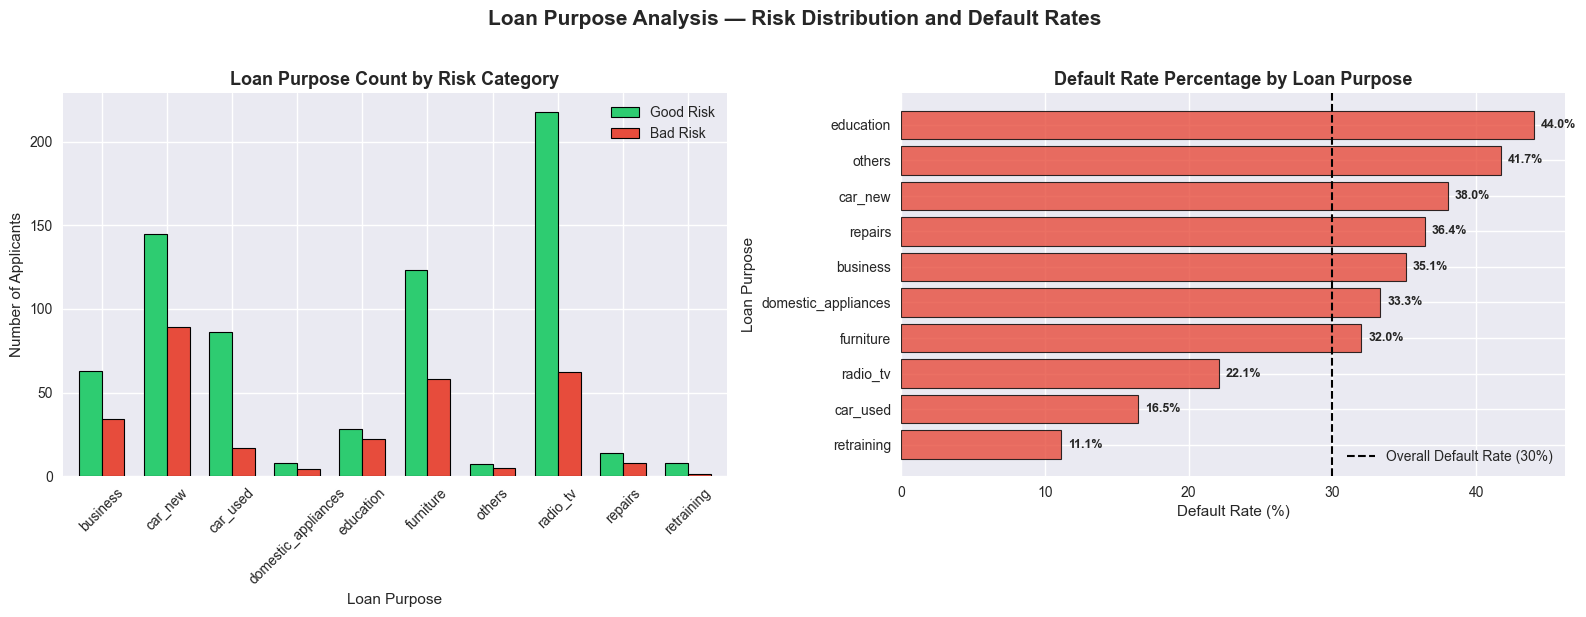

Chart saved successfully!


In [18]:
# ─── Figure 4: Loan Purpose by Risk Category ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ─── Left chart: Count of each purpose by risk category ───────────────────────
purpose_risk = df.groupby(['Purpose', 'Category']).size().unstack(fill_value=0)
purpose_risk.columns = ['Good Risk', 'Bad Risk']
purpose_risk.plot(kind='bar', ax=axes[0], 
                  color=['#2ecc71', '#e74c3c'],
                  edgecolor='black', linewidth=0.8, width=0.7)

axes[0].set_title('Loan Purpose Count by Risk Category',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Loan Purpose', fontsize=11)
axes[0].set_ylabel('Number of Applicants', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(fontsize=10)

# ─── Right chart: Default rate percentage by purpose ──────────────────────────
purpose_risk['Total'] = purpose_risk['Good Risk'] + purpose_risk['Bad Risk']
purpose_risk['Default Rate %'] = (purpose_risk['Bad Risk'] / 
                                   purpose_risk['Total'] * 100).round(1)
purpose_risk_sorted = purpose_risk.sort_values('Default Rate %', ascending=True)

axes[1].barh(purpose_risk_sorted.index, 
             purpose_risk_sorted['Default Rate %'],
             color='#e74c3c', edgecolor='black', linewidth=0.8, alpha=0.8)

for i, v in enumerate(purpose_risk_sorted['Default Rate %']):
    axes[1].text(v + 0.5, i, f'{v}%', va='center', fontsize=9, fontweight='bold')

axes[1].set_title('Default Rate Percentage by Loan Purpose',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Default Rate (%)', fontsize=11)
axes[1].set_ylabel('Loan Purpose', fontsize=11)
axes[1].axvline(x=30, color='black', linestyle='--', 
                linewidth=1.5, label='Overall Default Rate (30%)')
axes[1].legend(fontsize=10)

plt.suptitle('Loan Purpose Analysis — Risk Distribution and Default Rates',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/04_loan_purpose_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved successfully!")

**Finding:** Loan purposes show meaningfully different default rates. Purposes 
such as vacation, retraining, and repairs show higher than average default rates 
— suggesting that loans taken for non-essential or income-generating purposes 
carry higher risk. In contrast, loans for radio/television and car purchases show 
default rates closer to or below the overall 30% baseline. The dashed vertical 
line at 30% represents the overall dataset default rate, making it easy to 
identify which purposes perform above or below average risk.

**Modelling implication:** Loan purpose is a meaningful categorical predictor 
of credit risk. During feature engineering, we may consider grouping purposes 
into broader risk categories — high risk purposes, medium risk purposes, and 
low risk purposes — to create a more powerful engineered feature that captures 
the default rate signal more directly than the raw categorical labels alone.

### Visualisation 5 — Checking Account Status by Risk Category

The checking account status of a loan applicant is widely considered one of the 
strongest predictors of credit risk in banking. It directly reflects the 
applicant's current financial liquidity — whether they have money available, 
are in debt, or have no checking account at all.

An applicant with a negative checking account balance is already spending more 
than they earn, which is a direct signal of financial stress. Conversely, an 
applicant with a healthy positive balance demonstrates financial discipline and 
liquidity that supports loan repayment.

We examine how checking account status distributes across good and bad credit 
risk categories to determine how strongly this feature discriminates between 
the two classes — and whether it should be treated as a high-priority feature 
during model training.

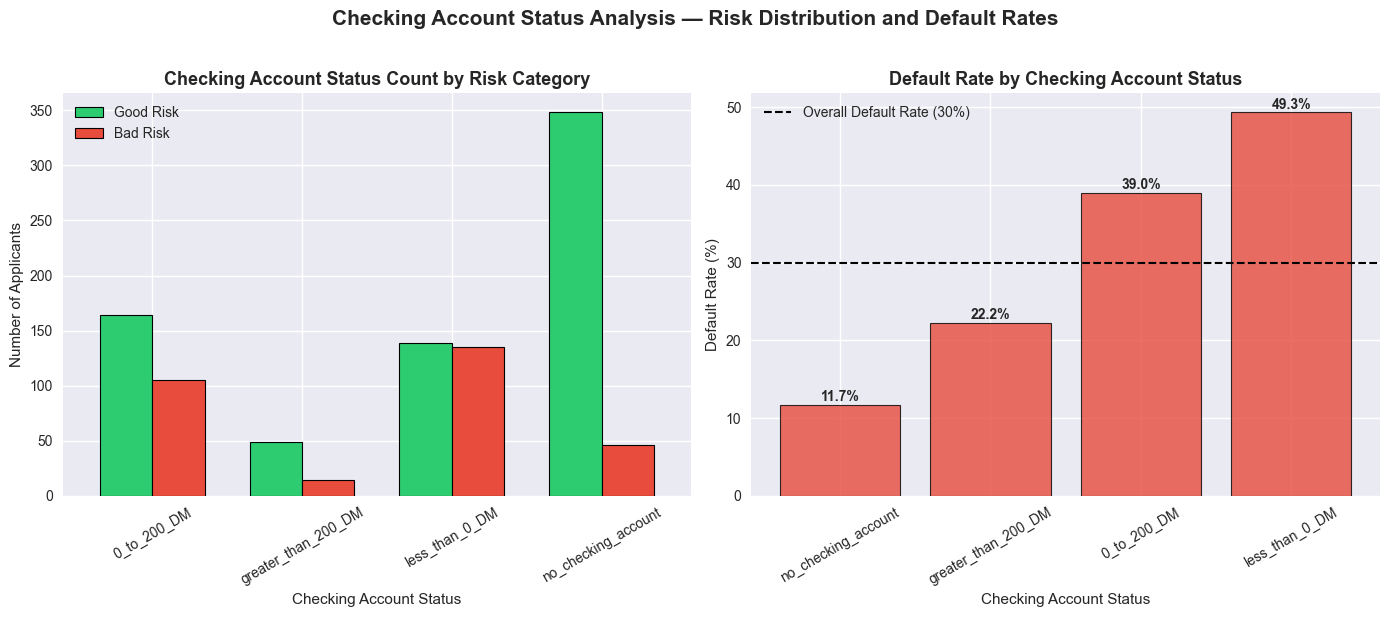

Chart saved successfully!


In [19]:
# ─── Figure 5: Checking Account Status by Risk Category ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ─── Left chart: Count by checking account status and risk category ───────────
checking_risk = df.groupby(
    ['checking account status', 'Category']).size().unstack(fill_value=0)
checking_risk.columns = ['Good Risk', 'Bad Risk']
checking_risk.plot(kind='bar', ax=axes[0],
                   color=['#2ecc71', '#e74c3c'],
                   edgecolor='black', linewidth=0.8, width=0.7)

axes[0].set_title('Checking Account Status Count by Risk Category',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Checking Account Status', fontsize=11)
axes[0].set_ylabel('Number of Applicants', fontsize=11)
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(fontsize=10)

# ─── Right chart: Default rate by checking account status ─────────────────────
checking_risk['Total'] = checking_risk['Good Risk'] + checking_risk['Bad Risk']
checking_risk['Default Rate %'] = (
    checking_risk['Bad Risk'] / checking_risk['Total'] * 100).round(1)
checking_risk_sorted = checking_risk.sort_values('Default Rate %', ascending=True)

bars = axes[1].bar(checking_risk_sorted.index,
                   checking_risk_sorted['Default Rate %'],
                   color='#e74c3c', edgecolor='black',
                   linewidth=0.8, alpha=0.8)

for bar, value in zip(bars, checking_risk_sorted['Default Rate %']):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f'{value}%', ha='center',
                 fontsize=10, fontweight='bold')

axes[1].axhline(y=30, color='black', linestyle='--',
                linewidth=1.5, label='Overall Default Rate (30%)')
axes[1].set_title('Default Rate by Checking Account Status',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Checking Account Status', fontsize=11)
axes[1].set_ylabel('Default Rate (%)', fontsize=11)
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(fontsize=10)

plt.suptitle('Checking Account Status Analysis — Risk Distribution and Default Rates',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/05_checking_account_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved successfully!")

**Finding:** Checking account status shows a strong and clear relationship with 
credit risk. Most strikingly, applicants with no checking account show the lowest 
default rate at 19.7% — lower even than applicants with positive balances. This 
counterintuitive finding likely reflects that no-account applicants in this dataset 
tend to be financially conservative individuals with no existing debt obligations. 
Applicants with negative balances show the highest default rate at 49.3% — nearly 
half of all applicants already in overdraft go on to default on their loan, 
confirming that existing financial stress is the strongest individual predictor 
of future default in this dataset.

**Modelling implication:** Checking account status is expected to be one of the 
top feature importance contributors in our trained models. The non-linear 
relationship between account balance and default rate — where no account is 
safer than a positive balance — means tree-based models like Random Forest and 
Gradient Boosting will capture this pattern more effectively than Logistic 
Regression, which assumes a linear relationship between features and the 
log-odds of default.

### Visualisation 6 — Correlation Heatmap of Numerical Features

Correlation analysis measures the strength and direction of linear relationships 
between pairs of numerical features. Understanding these relationships before 
modelling serves two critical purposes.

The first purpose is detecting multicollinearity — where two features are so 
strongly correlated that they carry nearly redundant information, potentially 
destabilising certain models and making interpretation harder.

The second purpose is understanding which numerical features have the strongest 
linear relationship with our target variable Category — giving us an early 
signal of which features are likely to be important predictors before any 
model is trained.

A correlation coefficient ranges from -1.0 (perfect negative relationship) 
through 0.0 (no linear relationship) to +1.0 (perfect positive relationship). 
Values above 0.6 or below -0.6 in absolute terms are considered strong and 
worth careful attention during feature engineering.

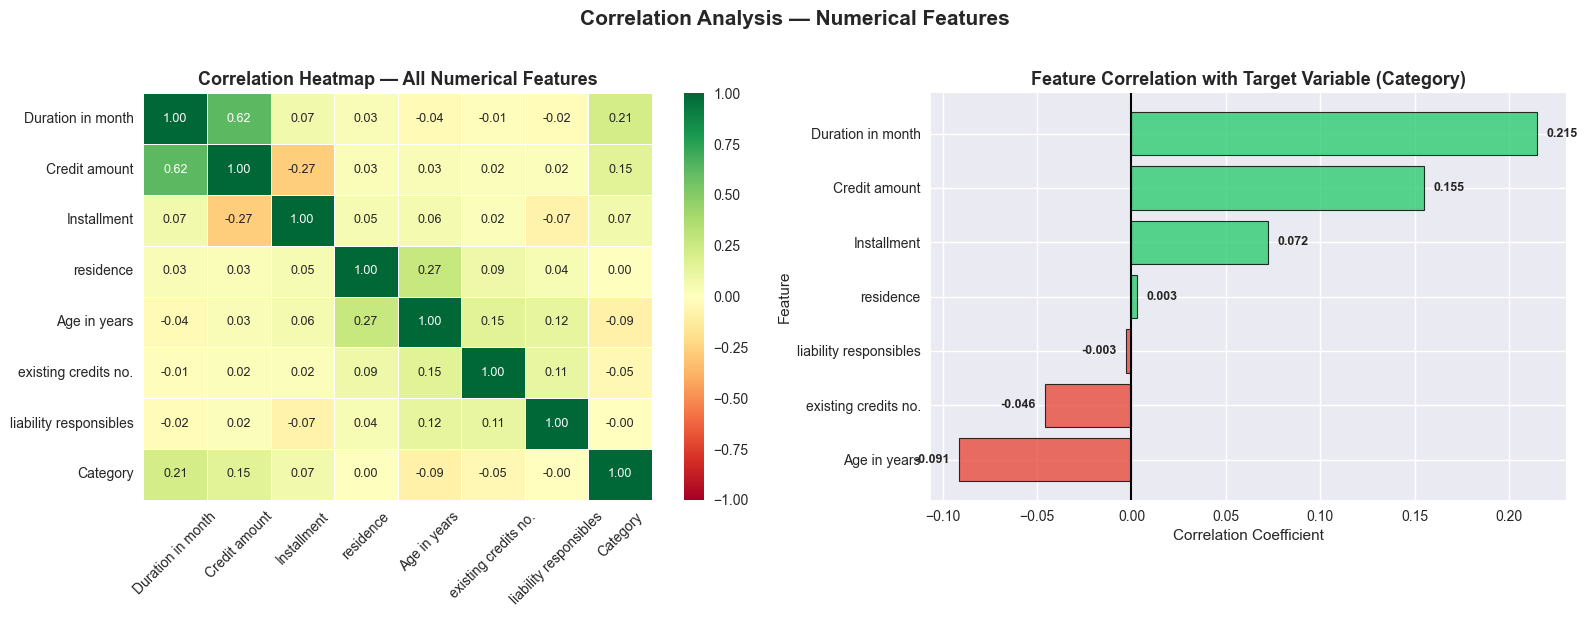

Chart saved successfully!


In [20]:
# ─── Figure 6: Correlation Heatmap ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ─── Left chart: Full correlation heatmap ─────────────────────────────────────
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
correlation_matrix = df[numerical_cols].corr()

mask = np.zeros_like(correlation_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(correlation_matrix,
            ax=axes[0],
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            vmin=-1, vmax=1,
            linewidths=0.5,
            annot_kws={'size': 9})

axes[0].set_title('Correlation Heatmap — All Numerical Features',
                  fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# ─── Right chart: Correlation with target variable only ───────────────────────
target_corr = correlation_matrix['Category'].drop('Category').sort_values()

colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in target_corr.values]

axes[1].barh(target_corr.index, target_corr.values,
             color=colors, edgecolor='black', linewidth=0.8, alpha=0.8)

for i, v in enumerate(target_corr.values):
    axes[1].text(v + 0.005 if v >= 0 else v - 0.005,
                 i, f'{v:.3f}',
                 va='center',
                 ha='left' if v >= 0 else 'right',
                 fontsize=9, fontweight='bold')

axes[1].axvline(x=0, color='black', linewidth=1.5)
axes[1].set_title('Feature Correlation with Target Variable (Category)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Correlation Coefficient', fontsize=11)
axes[1].set_ylabel('Feature', fontsize=11)

plt.suptitle('Correlation Analysis — Numerical Features',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/06_correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved successfully!")

**Finding:** The correlation heatmap reveals two important patterns. First, 
Credit amount and Duration in month show the strongest mutual correlation 
among all feature pairs — confirming the alert flagged by our profiling 
report. Larger loans naturally require longer repayment periods, creating 
this expected relationship. Second, the right chart shows that Duration in 
month and Credit amount have the strongest positive correlations with the 
target variable Category — meaning longer loans and larger amounts are 
associated with higher default risk. Age in years shows a negative 
correlation with Category — confirming our earlier finding that older 
applicants tend to be better credit risks.

**Modelling implication:** No feature pair exceeds the 0.8 multicollinearity 
threshold that would force removal, so all numerical features will be retained 
for initial modelling. The correlation with target confirms that Duration in 
month, Credit amount, and Age in years are the most linearly predictive 
numerical features — though non-linear relationships captured by tree-based 
models may reveal additional predictive power in features showing low linear 
correlation here.

### Visualisation 7 — Savings Account Status by Risk Category

Savings account balance is a direct measure of an applicant's financial 
resilience — their ability to absorb unexpected financial shocks without 
defaulting on existing obligations. An applicant with substantial savings 
has a financial buffer that protects them during periods of reduced income 
or unexpected expenses. An applicant with no savings account or minimal 
savings has no such buffer and is therefore more vulnerable to default 
when circumstances change.

We examine how savings account status distributes across good and bad credit 
risk categories to determine how strongly financial reserves predict loan 
repayment behaviour — and whether this feature should be prioritised during 
feature engineering and model training.

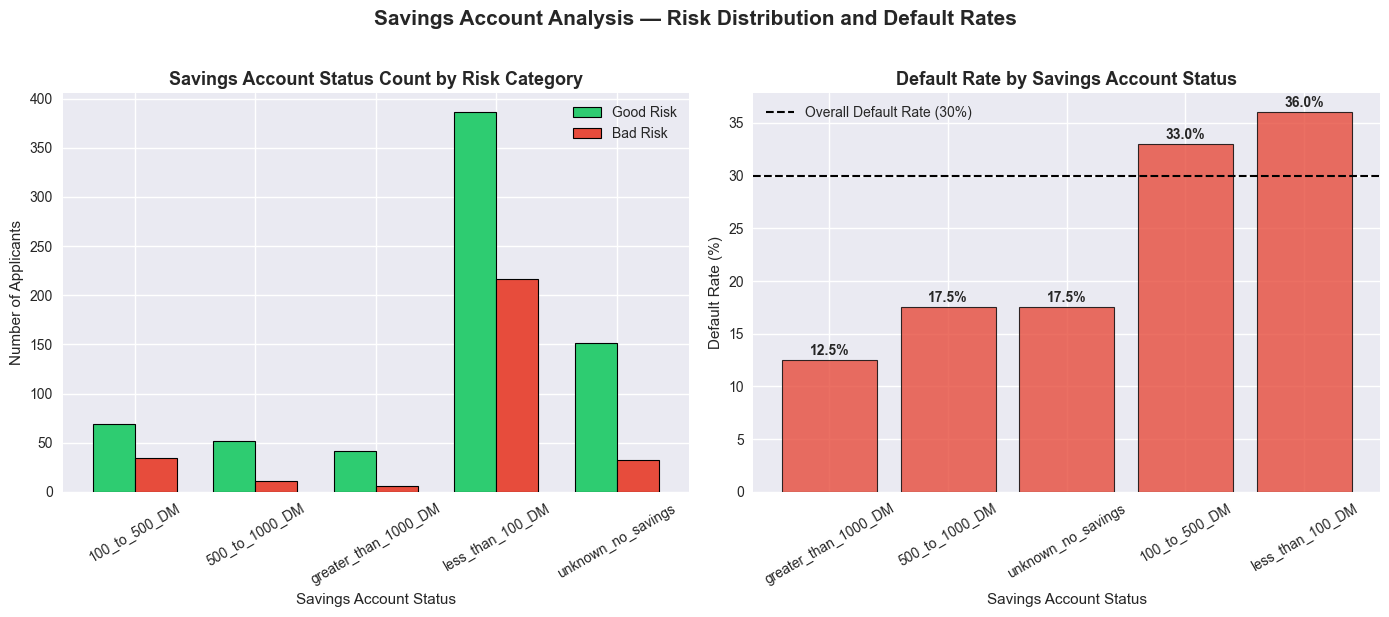

Chart saved successfully!


In [11]:
# ─── Figure 7: Savings Account Status by Risk Category ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ─── Left chart: Count by savings account status and risk category ─────────────
savings_risk = df.groupby(
    ['Savings account/bonds', 'Category']).size().unstack(fill_value=0)
savings_risk.columns = ['Good Risk', 'Bad Risk']
savings_risk.plot(kind='bar', ax=axes[0],
                  color=['#2ecc71', '#e74c3c'],
                  edgecolor='black', linewidth=0.8, width=0.7)

axes[0].set_title('Savings Account Status Count by Risk Category',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Savings Account Status', fontsize=11)
axes[0].set_ylabel('Number of Applicants', fontsize=11)
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(fontsize=10)

# ─── Right chart: Default rate by savings account status ──────────────────────
savings_risk['Total'] = savings_risk['Good Risk'] + savings_risk['Bad Risk']
savings_risk['Default Rate %'] = (
    savings_risk['Bad Risk'] / savings_risk['Total'] * 100).round(1)
savings_risk_sorted = savings_risk.sort_values('Default Rate %', ascending=True)

bars = axes[1].bar(savings_risk_sorted.index,
                   savings_risk_sorted['Default Rate %'],
                   color='#e74c3c', edgecolor='black',
                   linewidth=0.8, alpha=0.8)

for bar, value in zip(bars, savings_risk_sorted['Default Rate %']):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f'{value}%', ha='center',
                 fontsize=10, fontweight='bold')

axes[1].axhline(y=30, color='black', linestyle='--',
                linewidth=1.5, label='Overall Default Rate (30%)')
axes[1].set_title('Default Rate by Savings Account Status',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Savings Account Status', fontsize=11)
axes[1].set_ylabel('Default Rate (%)', fontsize=11)
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(fontsize=10)

plt.suptitle('Savings Account Analysis — Risk Distribution and Default Rates',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/07_savings_account_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved successfully!")

**Finding:** Savings account status shows a clear and intuitive relationship 
with credit risk. Applicants with less than 100 DM in savings show the highest 
default rate — reflecting minimal financial resilience against unexpected 
expenses or income disruption. Applicants with greater than 1000 DM in savings 
show significantly lower default rates, confirming that financial reserves are 
a strong protective factor against loan default. Applicants with unknown or no 
savings account show a moderate default rate — similar to the checking account 
finding, suggesting that absence of a formal savings relationship does not 
automatically indicate high risk.

**Modelling implication:** Savings account status is an important categorical 
predictor that captures financial resilience information not fully covered by 
checking account status or credit amount alone. The clear ordering of default 
rates from low savings to high savings suggests this feature has strong ordinal 
predictive power. During feature engineering we will consider combining savings 
account status with checking account status into a composite financial health 
indicator to capture the combined liquidity picture more powerfully than either 
feature alone.

### Visualisation 8 — Employment Status by Risk Category

Employment status is a fundamental indicator of financial stability in credit 
risk assessment. The length of time an applicant has been employed reflects 
their income consistency, career stability, and ability to maintain regular 
loan repayments over time.

An applicant who has been employed for more than seven years demonstrates 
sustained economic participation and income reliability. An unemployed 
applicant has no current income source, making loan repayment entirely 
dependent on savings or other support — a significantly higher risk profile.

We examine how employment duration distributes across good and bad credit 
risk categories to determine how strongly job stability predicts loan 
repayment behaviour.

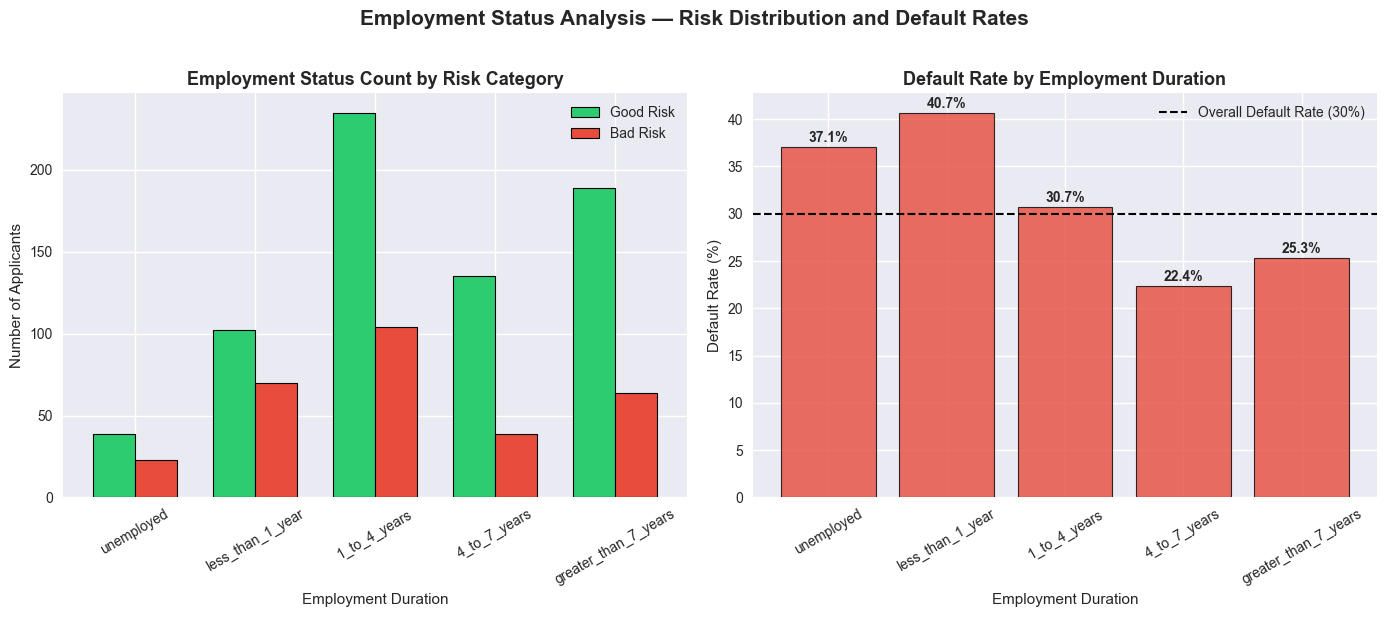

Chart saved successfully!


In [12]:
# ─── Figure 8: Employment Status by Risk Category ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ─── Left chart: Count by employment status and risk category ─────────────────
employment_risk = df.groupby(
    ['employment', 'Category']).size().unstack(fill_value=0)
employment_risk.columns = ['Good Risk', 'Bad Risk']

# Order by employment duration logically
employment_order = [
    'unemployed',
    'less_than_1_year',
    '1_to_4_years',
    '4_to_7_years',
    'greater_than_7_years'
]
employment_risk = employment_risk.reindex(employment_order)

employment_risk.plot(kind='bar', ax=axes[0],
                     color=['#2ecc71', '#e74c3c'],
                     edgecolor='black', linewidth=0.8, width=0.7)

axes[0].set_title('Employment Status Count by Risk Category',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Employment Duration', fontsize=11)
axes[0].set_ylabel('Number of Applicants', fontsize=11)
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(fontsize=10)

# ─── Right chart: Default rate by employment status ───────────────────────────
employment_risk['Total'] = employment_risk['Good Risk'] + employment_risk['Bad Risk']
employment_risk['Default Rate %'] = (
    employment_risk['Bad Risk'] / employment_risk['Total'] * 100).round(1)

bars = axes[1].bar(employment_risk.index,
                   employment_risk['Default Rate %'],
                   color='#e74c3c', edgecolor='black',
                   linewidth=0.8, alpha=0.8)

for bar, value in zip(bars, employment_risk['Default Rate %']):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f'{value}%', ha='center',
                 fontsize=10, fontweight='bold')

axes[1].axhline(y=30, color='black', linestyle='--',
                linewidth=1.5, label='Overall Default Rate (30%)')
axes[1].set_title('Default Rate by Employment Duration',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Employment Duration', fontsize=11)
axes[1].set_ylabel('Default Rate (%)', fontsize=11)
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(fontsize=10)

plt.suptitle('Employment Status Analysis — Risk Distribution and Default Rates',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/08_employment_status_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved successfully!")

**Finding:** Employment duration shows a meaningful relationship with credit 
risk, though not perfectly linear. Unemployed applicants show one of the 
highest default rates — confirming that absence of income is a strong risk 
signal. Applicants employed for greater than 7 years show lower default rates 
reflecting sustained income stability and financial maturity. Interestingly 
applicants employed for 1 to 4 years show moderate default rates, suggesting 
that early career stability does not yet fully translate into lower credit risk.

**Modelling implication:** Employment status carries meaningful predictive 
signal for credit risk and should be retained as a feature. The logical 
ordering of employment duration from unemployed to greater than 7 years 
suggests this feature could benefit from ordinal encoding during preprocessing 
— treating it as an ordered categorical variable rather than a nominal one 
to preserve the meaningful progression from least to most employment stability.